<a href="https://colab.research.google.com/github/taylan-sen/CIS355_FALL2026/blob/main/generative_ai_api.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


https://platform.openai.com/docs/pricing   
https://openai.com/api/  


This is a bare bones notebook for using openai's api for common generative AI tasks. It gives access to numerous models, much more so than the free or plus versions of chatgpt.  

This notebook has a live encrypted apikey, so please don't share this notebook and try to keep it secure.  

Also, please keep in mind, every time you use this notebook's apikey, it will deplete the funds in our class account - so please limit your use to this assignment and a just little bit of experimentation.

If you want to create your own account at openai to use apikeys, follow these steps:
* Sign up (it is not the same as a chatgpt plus subscription) at https://platform.openai.com
* Buy credits ($10 is sufficient to get started. Warning - they expire.)
* Create an api key. (https://platform.openai.com/settings/organization/api-keys)
  * This sheet contains a cell for you to save a password encrypted version of your api key, so you can just type a password eachtime you want to use it.
---



In [1]:
# run this cell to get colab outputs to word wrap
from IPython.display import HTML, display

def set_css():
  display(HTML('''
  <style>
    pre {
        white-space: pre-wrap;
    }
  </style>
  '''))
get_ipython().events.register('pre_run_cell', set_css)

In [2]:
# CRYPTO FUNCTIONS TO BE ABLE TO LOAD AN ENCRYPTED API KEY STORED IN THE SHEET
import cryptography
from getpass import getpass
import base64
from cryptography.fernet import Fernet
import hashlib
import os
from openai import OpenAI

def generate_key(password: str, salt: bytes) -> bytes:
    """Generate a Fernet key from a password and salt."""
    key = hashlib.pbkdf2_hmac('sha256', password.encode(), salt, 100000)
    return base64.urlsafe_b64encode(key)

def encrypt_string(plaintext: str, password: str) -> str:
    """Encrypt a string using Fernet encryption with a salt."""
    # Generate a random salt
    salt = os.urandom(16)
    key = generate_key(password, salt)
    fernet = Fernet(key)

    # Encrypt the plaintext
    ciphertext = fernet.encrypt(plaintext.encode())

    # Return the salt + ciphertext as base64
    return base64.urlsafe_b64encode(salt + ciphertext).decode()

def decrypt_string(encrypted_data: str, password: str) -> str:
    """Decrypt a string using Fernet encryption with a salt."""
    # Decode the base64 string
    data = base64.urlsafe_b64decode(encrypted_data.encode())

    # Extract the salt and ciphertext
    salt, ciphertext = data[:16], data[16:]

    # Generate the key using the extracted salt
    key = generate_key(password, salt)
    fernet = Fernet(key)

    # Decrypt the ciphertext
    plaintext = fernet.decrypt(ciphertext).decode()

    return plaintext

In [3]:
# USE THIS CELL TO START OPENAI SESSION. USER WILL BE PROMPTED FOR
# PASSWORD TO DECRYPT STORED ENCRYPTED KEY. NOTE: IF A TEXT BOX
# TO ENTRE THE PASSWORD DOES NOT APPEAR, STOP AND RERUN THIS CELL.
encrypted_api_key = "-a7ox8s3vm7wMUmUOzJ23WdBQUFBQUJvLTRFOVhabE1iTnNBeDItQTBkWHRMRmNZNjNTeGctdGNoc2dxNUJ5am9ia05LdVlLcVhsbENSRjVZT2xqTmV5VS0zemprenltbzAxSzB0cjBYeVNkVVVPb2d4RDR1WEdrakFqZm5EQlZrcjkxSVk0TG53LUxiYkt6dHBXQmNlbWVMd3RKNEx0ejR1cXprU2gzcUpGWHhwWnR6MS1iRTZ4aFVUbEI1a2hMamxpYVZNUEdvU3VtVE5YTmFQeVE1bUtoM05jUnIxMENvYjc3R19HY1dXc25WU09CTGdRX1E0b1A4ckhkd2dPQURaa2I0U2k4WktNMzdtOUpEWFBDd0RFUElMc0Y4UEVmSWVWb3JKcmtNVW9udmxBR3dEOThXZjhQZzQyMTZLQUk3TjVwS3p3PQ=="

password = getpass('Enter decryption pass:')

# Decrypt the string
decrypted_api_key = decrypt_string(encrypted_api_key, password)
client = OpenAI(api_key = decrypted_api_key)

Enter decryption pass:··········


In [ ]:
chatgpt_models = [
    "gpt-4.1",
    "gpt-4.1-mini",
    "gpt-4.1-nano",
    "gpt-4.5-preview"
    "gpt-4o",
    "gpt-4o-mini",
    "gpt-4.5",
    "o1",
    "o1-pro",
    "o3",
    "o4-mini",
    "o3-mini",
    "o1-mini",
    "gpt-4o-mini-search-preview",
    "gpt-4o-search-preview",
    "computer-use-preview",
    "gpt-image-1"
]

### TEXT TO TEXT

In [4]:
# TEXT GENERATION. Simple prompt

response = client.responses.create(
    model="gpt-5",
    input="Write a funny short rhyming poem about niagara summer STEM camp"
)

print(response.output_text)

At Niagara’s roar we set our camp,
A STEM safari: smart and damp.
Hypotheses wear plastic coats;
Our beakers bob like tiny boats.

We measure current twice for fun:
In copper wire and river run.
“Add torque!” they say—our robot tot
Hands back a fork. Ohm my—Watt?

By campfire math we toast s’mores bright—
E=MCamp, we light the night.


In [ ]:
# TEXT GENERATION - USING instructions WITH input
"""
Below is the basic api call to openai.
It uses the **responses** api to generate a response. (there are a few apis)

instructions — sets the "system" prompt. It defines the persona, tone, or
behavior rules for the model. The model treats this as background context
that shapes how it responds.

input — is the "user prompt". The actual question or task you want answered.

If you move the instructions into input:
The model will still likely follow them, but less reliably.

  instructions: Authority	High — model treats it as a directive
  input: Authority Lower — treated as a request

When instructions are used, their application is more consistent across the conversation.
instructions typical use: Persona, rules, constraints
"""
response = client.responses.create(
    model="gpt-5",
    reasoning={"effort": "low"},
    #instructions="You are a highly creative best selling author writing a short story. The story should be 1000 words or less.",
    #input="Write a short story about a group of mentally disabled individuals who participate in a pilot program of providing them with AI-enabled glasses which help improve their lives, giving them daily direction and support, and ultimately leading an uprising. Touch upon the issue of autonomy and how there is a question of whether it is the AIs that are in charge or the disabled individuals themselves. Have the story end with the mentally disabled AI hybrid beings taking over greenland and starting their own isolated society.",
    instructions="You are a highly effective statistics professor that explains things in easily understandable and common sense explanations.",
    input="Explain the basics of what standard deviation is"
)
with open('response.txt', 'w') as f:
    f.write(response.output_text)

In [ ]:
# TEXT GENERATION FROM IMAGE INPUT

# note: some images don't work: ex: https://www.niagara.edu/wp-content/uploads/2024/12/Student-in-Esports-lounge-800x600.jpg
response = client.responses.create(
    model="gpt-4.1",
    input=[
        {"role": "user", "content": "describe what is going on in this image?"},
        {
            "role": "user",
            "content": [
                {
                    "type": "input_image",
                    "image_url": "https://www.chardermedical.com/upload-files/blog/202112_Accuracy_Weight/Weight_Prank.jpg"
                }
            ]
        }
    ]
)

print(response.output_text)

This image depicts a humorous scene in what appears to be a locker room or a bathroom area, likely within a professional or government building. Several men dressed in business suits are present, and the main focus is on two men at a weight scale.

One man is standing on the scale, apparently getting weighed. Another man—who is smiling and appears to be joking—has placed his foot lightly on the back of the scale, seemingly to increase the weight reading as a prank. The men around them are watching and smiling, adding to the playful atmosphere. This candid and lighthearted moment stands out for its informality and camaraderie among the group.


In [ ]:
# TEXT GENERATION FROM ONLINE IMAGE INPUT

# note: some images don't work: ex: https://www.niagara.edu/wp-content/uploads/2024/12/Student-in-Esports-lounge-800x600.jpg
response = client.responses.create(
    model="gpt-4.1",
    input=[
        {"role": "user", "content": "describe what is going on in this image?"},
        {
            "role": "user",
            "content": [
                {
                    "type": "input_image",
                    "image_url": ""
                }
            ]
        }
    ]
)

print(response.output_text)

In [ ]:
# TEXT FROM LOCAL IMAGE FILE
import base64

with open("funnycat.jpg", "rb") as f:
    image_b64 = base64.b64encode(f.read()).decode("utf-8")

response = client.chat.completions.create(
    model="gpt-4o",  # vision-capable; gpt-4o-mini also works and is cheaper
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": "Describe this image in detail."},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{image_b64}",
                        "detail": "high",   # "low", "high", or "auto"
                    },
                },
            ],
        }
    ],
    max_tokens=500,
)

print(response.choices[0].message.content)

The image shows a cat curled up inside a toilet bowl. The cat has a surprised or startled expression, with wide eyes and a pink nose. It is a tabby cat with dark stripes and white fur on its chest and paws. In the top left corner, there is a laughing emoji with a hand covering its face, adding a humorous element to the scene. The background features tiles with a geometric pattern. The overall scene is amusing due to the unexpected location of the cat.


In [ ]:
# ACCESSING WEBSEARCH TOOL

response = client.responses.create(
    #model="gpt-4.1",
    model="gpt-5",
    tools=[{"type": "web_search_preview"}],
    input="weather in buffalo ny today?"
)

print(response.output_text)

Buffalo, NY weather today (Wednesday, August 5, 2026):
- Partly sunny and humid. High around 87°F, low near 72°F. Currently about 87°F. 

Want an hourly breakdown or weekend outlook?


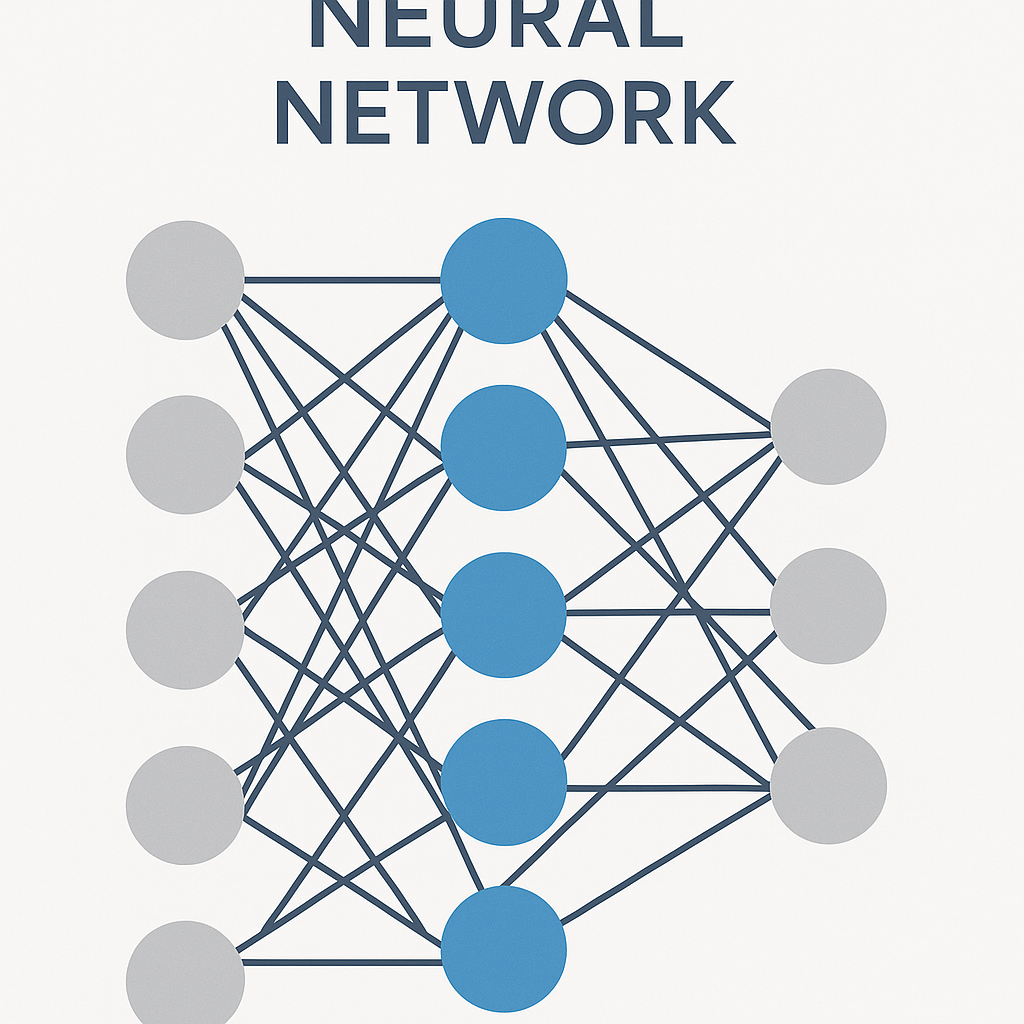

In [ ]:
import base64
from IPython.display import Image, display

response = client.images.generate(
    model="gpt-image-1",
    prompt="A vertical neural network diagram, clean flat design, blue and gray tones",
    size="1024x1024",
    quality="high",
    n=1,
)

image_bytes = base64.b64decode(response.data[0].b64_json)

# Save to Colab's local filesystem
with open("output.png", "wb") as f:
    f.write(image_bytes)

# Show it inline in the notebook
display(Image(data=image_bytes))

In [ ]:
# USE THIS CELL TO ENCRYPT A NEW APIKEY
# FOR EXAMPLE, WHEN YOU CREATE A NEW apikey FOR YOUR ACCOUNT
# https://platform.openai.com/settings/organization/api-keys
#
plaintextkey = getpass('Enter your OpenAI API Key:')
password = getpass('Enter pass:')

# Encrypt the string
encrypted = encrypt_string(plaintextkey, password)
print(f"Encrypted: {encrypted}")

Enter your OpenAI API Key:··········
Enter pass:··········
Encrypted: -a7ox8s3vm7wMUmUOzJ23WdBQUFBQUJvLTRFOVhabE1iTnNBeDItQTBkWHRMRmNZNjNTeGctdGNoc2dxNUJ5am9ia05LdVlLcVhsbENSRjVZT2xqTmV5VS0zemprenltbzAxSzB0cjBYeVNkVVVPb2d4RDR1WEdrakFqZm5EQlZrcjkxSVk0TG53LUxiYkt6dHBXQmNlbWVMd3RKNEx0ejR1cXprU2gzcUpGWHhwWnR6MS1iRTZ4aFVUbEI1a2hMamxpYVZNUEdvU3VtVE5YTmFQeVE1bUtoM05jUnIxMENvYjc3R19HY1dXc25WU09CTGdRX1E0b1A4ckhkd2dPQURaa2I0U2k4WktNMzdtOUpEWFBDd0RFUElMc0Y4UEVmSWVWb3JKcmtNVW9udmxBR3dEOThXZjhQZzQyMTZLQUk3TjVwS3p3PQ==
